# 🧬 Embedding Dimension Interpretation via Clinical Features

**Purpose**: Understand **what clinical information each embedding dimension captures** by correlating embeddings with ALL baseline features.

---

## 🎯 Key Question:

**"What does each embedding dimension represent in terms of actual clinical characteristics?"**

For example:
- Does `embedding_42` correlate with prior hospitalizations?
- Does `embedding_137` capture chronic disease burden (CHF, COPD, etc.)?
- Does `embedding_5` encode age + expenditure patterns?
- Are there dimensions that capture medication usage?

---

## 📋 Analysis Workflow:

| Step | Description | Output |
|------|-------------|--------|
| **1. Load Data** | Embeddings (256D) + All baseline features (~50+ features) | Single merged dataset |
| **2. Rank Dimensions** | Identify top N most IP-predictive embedding dimensions | Top 30 dimensions |
| **3. Correlation Matrix** | Calculate correlation between each embedding dim × each feature | 30 × 50+ matrix |
| **4. Heatmap Visualization** | Show which features "explain" each dimension | Interpretable heatmap |
| **5. Dimension Profiles** | Describe each top dimension in clinical terms | Narrative interpretation |

---

## 🔍 Why This Matters:

1. **Explainability**: Understand what the transformer learned
2. **Trust**: Verify embeddings capture clinically meaningful patterns
3. **Debugging**: Identify if embeddings miss important clinical info
4. **Feature Engineering**: Guide creation of new baseline features
5. **Clinical Validation**: Ensure dimensions align with domain knowledge

---

**Created**: January 2026  
**Related Notebooks**:  
- `medicare_ip_embedding_cluster_analysis.ipynb` - Embeddings clustering (Cohen's D = 0.691)
- `medicare_ip_baseline_features_cluster_analysis.ipynb` - Baseline clustering (Cohen's D = 0.508)

---

## 0. Setup & Configuration

In [10]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.cloud import bigquery
import time
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# BigQuery client
client = bigquery.Client()

print("✅ Environment ready!")

✅ Environment ready!


In [11]:
# ==============================================================================
# 📝 CONFIGURATION
# ==============================================================================

# EMBEDDING TABLE (256D transformer embeddings)
EMBEDDING_TABLE = "edp-prod-storage.edp_ent_sdoheir_cns.a964286_te4exp_3lob_exp_round5_v2_exp1_dense_baseline_opt_config_medicare_all_sample_embedding"
EMBEDDING_NAME = "opt_config"

# BASELINE FEATURES TABLE (ALL clinical features - not just the 52 production features)
FEATURE_TABLE = "edp-prod-storage.edp_ent_sdoheir_cns.a834793_Medicare_holdout_members_with_features"

# OUTCOME (for ranking embedding dimensions by predictiveness)
OUTCOME_COLUMN = "ip6"
OUTCOME_LABEL = "IP Admission"

# JOIN KEYS
JOIN_KEYS = ['individual_id', 'index_dt']

# ANALYSIS PARAMETERS
TOP_N_DIMENSIONS = 30  # Focus on top N most predictive embedding dimensions
TOP_N_FEATURES_PER_DIM = 10  # Show top N correlated features per dimension
CORRELATION_THRESHOLD = 0.10  # Minimum |r| to consider "meaningful"

print("="*80)
print("✅ CONFIGURATION LOADED - EMBEDDING INTERPRETATION")
print("="*80)
print(f"\n🧬 Embedding Source: {EMBEDDING_NAME}")
print(f"   Table: {EMBEDDING_TABLE.split('.')[-1][:60]}...")
print(f"\n📊 Baseline Features: {FEATURE_TABLE.split('.')[-1]}")
print(f"\n🎯 Analysis Focus:")
print(f"   - Top {TOP_N_DIMENSIONS} most predictive embedding dimensions")
print(f"   - Correlate with ALL available baseline features (~50+)")
print(f"   - Identify clinical meaning of each dimension")
print(f"\n⚙️ Correlation Threshold: |r| ≥ {CORRELATION_THRESHOLD} (meaningful)")
print("="*80)

✅ CONFIGURATION LOADED - EMBEDDING INTERPRETATION

🧬 Embedding Source: opt_config
   Table: a964286_te4exp_3lob_exp_round5_v2_exp1_dense_baseline_opt_co...

📊 Baseline Features: a834793_Medicare_holdout_members_with_features

🎯 Analysis Focus:
   - Top 30 most predictive embedding dimensions
   - Correlate with ALL available baseline features (~50+)
   - Identify clinical meaning of each dimension

⚙️ Correlation Threshold: |r| ≥ 0.1 (meaningful)


---

## 1. Load Data

**What this section does:**
- Loads transformer embeddings (256D)
- Loads ALL baseline clinical features
- Joins datasets on `individual_id` + `index_dt`
- Loads IP outcome for ranking dimensions

**Expected result:**
- Single dataframe with:
  - `embedding_0` ... `embedding_255` (256 columns)
  - All clinical features (50+ features)
  - `ip6` (outcome for ranking)

### 1.1 Load Embeddings + Features + Outcome (Single Query)

In [12]:
print("📥 Loading embeddings + features + outcome...")
print(f"   This will join {EMBEDDING_NAME} embeddings with baseline features\n")
start_time = time.time()

# Load embeddings
print("⏳ Step 1/3: Loading embeddings...")
embeddings_sql = f"""
    SELECT *
    FROM `{EMBEDDING_TABLE}`
"""
df_embeddings = client.query(embeddings_sql).to_dataframe()
print(f"   ✅ Embeddings: {df_embeddings.shape[0]:,} rows")

# Load features
print("\n⏳ Step 2/3: Loading baseline features...")
features_sql = f"""
    SELECT *
    FROM `{FEATURE_TABLE}`
"""
df_features = client.query(features_sql).to_dataframe()
print(f"   ✅ Features: {df_features.shape[0]:,} rows, {df_features.shape[1]} columns")

# Fix data types for join
print("\n⏳ Step 3/3: Joining datasets...")
for key in JOIN_KEYS:
    if 'id' in key.lower():
        df_embeddings[key] = df_embeddings[key].astype(str)
        df_features[key] = df_features[key].astype(str)
    elif 'dt' in key.lower() or 'date' in key.lower():
        df_embeddings[key] = pd.to_datetime(df_embeddings[key]).dt.date
        df_features[key] = pd.to_datetime(df_features[key]).dt.date

# Join
df = df_embeddings.merge(df_features, on=JOIN_KEYS, how='inner')
load_time = time.time() - start_time

if len(df) == 0:
    raise ValueError("❌ ERROR: No data after join! Check JOIN_KEYS.")

# Identify columns
embedding_cols = [col for col in df.columns if col.startswith('embedding_')]

# ID/Key columns to exclude (metadata, not clinical features)
id_cols = ['individual_id', 'member_id', 'holdout_id', 'index_dt', 'feature_end_dt', 
           'business_ln_cd', 'mon_6_include', 'gender_cd', 'cd', 'dt_cnt']

# Outcome columns to exclude (target variables, not input features)
# ⚠️ IMPORTANT: Only exclude the TARGET outcome (ip6), NOT historical utilization features
# Historical features like camemmedcasedc1_ip_cnt_dc1 are INPUTS, not outcomes!
outcome_cols = [OUTCOME_COLUMN]  # Only exclude 'ip6' (the target)
if 'target' in df.columns:
    outcome_cols.append('target')
if 'sum_ip6_admits' in df.columns:
    outcome_cols.append('sum_ip6_admits')
if 'sum_ip6_los' in df.columns:
    outcome_cols.append('sum_ip6_los')

# All remaining numeric columns = features for correlation
# ✅ This will include historical utilization features (camemmedcase*, etc.)
exclude_cols = set(id_cols + outcome_cols + embedding_cols + JOIN_KEYS)
feature_cols = [col for col in df.columns 
                if col not in exclude_cols
                and df[col].dtype in ['int64', 'float64', 'int32', 'float32', 'Int64', 'Float64']]

print(f"\\n📋 Column Classification:")
print(f"   - ID/Key columns: {len(id_cols)} excluded")
print(f"   - Outcome columns: {len(outcome_cols)} excluded ({outcome_cols})")
print(f"   - Embedding dimensions: {len(embedding_cols)}")
print(f"   - Clinical features: {len(feature_cols)} ✅")

print(f"\n✅ Data loaded and joined: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"   Load time: {load_time:.1f} seconds")
print(f"\n📊 Data breakdown:")
print(f"   - Embedding dimensions: {len(embedding_cols)}")
print(f"   - Clinical features: {len(feature_cols)}")
print(f"   - Outcome ({OUTCOME_COLUMN}): {df[OUTCOME_COLUMN].mean()*100:.2f}% positive")

print(f"\n📊 Clinical feature categories:")
prefixes = {}
for col in feature_cols:
    prefix = col.split('_')[0] if '_' in col else 'other'
    prefixes[prefix] = prefixes.get(prefix, 0) + 1
for prefix, count in sorted(prefixes.items(), key=lambda x: -x[1])[:10]:
    print(f"   - {prefix}: {count} features")

print(f"\n✅ Ready for correlation analysis!")

📥 Loading embeddings + features + outcome...
   This will join opt_config embeddings with baseline features

⏳ Step 1/3: Loading embeddings...
   ✅ Embeddings: 836,844 rows

⏳ Step 2/3: Loading baseline features...
   ✅ Features: 2,789,480 rows, 66 columns

⏳ Step 3/3: Joining datasets...
\n📋 Column Classification:
   - ID/Key columns: 10 excluded
   - Outcome columns: 4 excluded (['ip6', 'target', 'sum_ip6_admits', 'sum_ip6_los'])
   - Embedding dimensions: 256
   - Clinical features: 52 ✅

✅ Data loaded and joined: 836,849 rows, 324 columns
   Load time: 77.2 seconds

📊 Data breakdown:
   - Embedding dimensions: 256
   - Clinical features: 52
   - Outcome (ip6): 7.14% positive

📊 Clinical feature categories:
   - camemhpd: 11 features
   - camemeipprcdc1: 5 features
   - camemmedutilization: 4 features
   - camemylm: 4 features
   - camemmedcasedc1: 2 features
   - camemmedcasedc2: 2 features
   - camemrxclassutilizationdc5: 2 features
   - camemrxgrouputilizationdc1: 2 features
   -

### 1.2 Data Quality Check & Preprocessing

**What this does:**
- Checks for missing values in features and embeddings
- Checks for infinite values
- Cleans data for robust correlation analysis

**Why this matters:**
- Correlation calculations can be sensitive to missing/infinite values
- We handle missing values via pairwise correlation (only use valid pairs)
- Infinite values need to be replaced to avoid calculation errors


In [13]:
print("🔍 Data Quality Check...\\n")

# 1. Check missing values
print("1️⃣ MISSING VALUES:")
print(f"   Embeddings:")
emb_missing = df[embedding_cols].isna().sum().sum()
emb_total = len(df) * len(embedding_cols)
print(f"      Total: {emb_missing:,} / {emb_total:,} ({emb_missing/emb_total*100:.2f}%)")

print(f"\\n   Baseline Features:")
feat_missing = df[feature_cols].isna().sum()
feats_with_missing = feat_missing[feat_missing > 0]
if len(feats_with_missing) > 0:
    print(f"      Features with missing values: {len(feats_with_missing)}/{len(feature_cols)}")
    print(f"      Top 5 features by missing count:")
    for feat, count in feats_with_missing.sort_values(ascending=False).head(5).items():
        pct = count / len(df) * 100
        print(f"         - {feat[:50]:<50} {count:>8,} ({pct:>5.1f}%)")
else:
    print(f"      ✅ No missing values!")

# 2. Check infinite values
print(f"\\n2️⃣ INFINITE VALUES:")
print(f"   Embeddings:")
emb_inf = df[embedding_cols].apply(lambda x: np.isinf(x).sum()).sum()
print(f"      Total: {emb_inf:,} {'✅' if emb_inf == 0 else '⚠️'}")

print(f"\\n   Baseline Features:")
feat_inf = df[feature_cols].apply(lambda x: np.isinf(x).sum())
feats_with_inf = feat_inf[feat_inf > 0]
if len(feats_with_inf) > 0:
    print(f"      Features with infinite values: {len(feats_with_inf)}/{len(feature_cols)} ⚠️")
    for feat, count in feats_with_inf.items():
        print(f"         - {feat[:50]:<50} {count:>8,}")
else:
    print(f"      ✅ No infinite values!")

# 3. Clean infinite values (replace with NaN for masking in correlation)
if len(feats_with_inf) > 0:
    print(f"\\n⚙️ Cleaning infinite values...")
    for col in feats_with_inf.index:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    print(f"   ✅ Replaced {len(feats_with_inf)} features' infinite values with NaN")
    print(f"   💡 These will be handled via pairwise correlation (skip invalid pairs)")

# 4. Data quality summary
print(f"\\n3️⃣ DATA QUALITY SUMMARY:")
print(f"   Total samples: {len(df):,}")
print(f"   Embeddings: {len(embedding_cols)} dimensions, {emb_missing} missing, {emb_inf} infinite")
print(f"   Features: {len(feature_cols)} features")

valid_samples_per_feature = df[feature_cols].notna().sum()
min_valid = valid_samples_per_feature.min()
max_valid = valid_samples_per_feature.max()
mean_valid = valid_samples_per_feature.mean()

print(f"   Valid samples per feature: min={min_valid:,}, mean={mean_valid:,.0f}, max={max_valid:,}")

if min_valid < 100:
    print(f"\\n   ⚠️ WARNING: Some features have < 100 valid samples!")
    print(f"   These will be excluded from correlation (require ≥ 100 pairs)")
    sparse_features = valid_samples_per_feature[valid_samples_per_feature < 100]
    print(f"   Sparse features: {len(sparse_features)}")
    for feat, count in sparse_features.items():
        print(f"      - {feat[:50]:<50} {count:>8,} valid")

print(f"\\n✅ Data quality check complete!")
print(f"   → Correlation will use pairwise-complete observations")
print(f"   → Pairs with < 100 valid observations will be set to r=0")


🔍 Data Quality Check...\n
1️⃣ MISSING VALUES:
   Embeddings:
      Total: 0 / 214,233,344 (0.00%)
\n   Baseline Features:
      ✅ No missing values!
\n2️⃣ INFINITE VALUES:
   Embeddings:
      Total: 0 ✅
\n   Baseline Features:
      ✅ No infinite values!
\n3️⃣ DATA QUALITY SUMMARY:
   Total samples: 836,849
   Embeddings: 256 dimensions, 0 missing, 0 infinite
   Features: 52 features
   Valid samples per feature: min=836,849, mean=836,849, max=836,849
\n✅ Data quality check complete!
   → Correlation will use pairwise-complete observations
   → Pairs with < 100 valid observations will be set to r=0


---

## 2. Rank Embedding Dimensions by IP Predictiveness

**What this section does:**
- Calculates correlation between each embedding dimension and IP outcome
- Ranks dimensions by absolute correlation
- Identifies the **top N most predictive dimensions** to focus interpretation on

**Why this matters:**
- Not all 256 dimensions are equally important for IP prediction
- We want to interpret the dimensions that actually drive the model's performance
- This focuses our attention on clinically relevant dimensions

In [14]:
print(f"🔍 Ranking embedding dimensions by {OUTCOME_LABEL} correlation...\n")

y_outcome = df[OUTCOME_COLUMN].values

# Calculate correlation for each embedding dimension
dim_correlations = []
for col in embedding_cols:
    corr, pval = stats.pointbiserialr(y_outcome, df[col])
    dim_correlations.append({
        'dimension': col,
        'correlation': corr,
        'abs_correlation': abs(corr),
        'pval': pval
    })

df_dim_corr = pd.DataFrame(dim_correlations).sort_values('abs_correlation', ascending=False)

print(f"📊 Top {TOP_N_DIMENSIONS} Most Predictive Embedding Dimensions:")
display(df_dim_corr.head(TOP_N_DIMENSIONS))

# Select top dimensions for detailed interpretation
top_dimensions = df_dim_corr.head(TOP_N_DIMENSIONS)['dimension'].tolist()

print(f"\n✅ Will interpret these {len(top_dimensions)} dimensions in detail")
print(f"\n📈 Correlation Summary:")
print(f"   Max |r|: {df_dim_corr['abs_correlation'].max():.4f}")
print(f"   Mean |r|: {df_dim_corr['abs_correlation'].mean():.4f}")
print(f"   Dimensions with |r| > {CORRELATION_THRESHOLD}: {(df_dim_corr['abs_correlation'] > CORRELATION_THRESHOLD).sum()}/{len(embedding_cols)}")

🔍 Ranking embedding dimensions by IP Admission correlation...

📊 Top 30 Most Predictive Embedding Dimensions:


,dimension,correlation,abs_correlation,pval
186,embedding_186,0.187644,0.187644,0.0
38,embedding_38,0.156249,0.156249,0.0
97,embedding_97,0.152235,0.152235,0.0
41,embedding_41,-0.147457,0.147457,0.0
217,embedding_217,0.126521,0.126521,0.0
147,embedding_147,0.125504,0.125504,0.0
197,embedding_197,0.121110,0.121110,0.0
113,embedding_113,-0.115556,0.115556,0.0
76,embedding_76,0.115310,0.115310,0.0
112,embedding_112,-0.115094,0.115094,0.0



✅ Will interpret these 30 dimensions in detail

📈 Correlation Summary:
   Max |r|: 0.1876
   Mean |r|: 0.0514
   Dimensions with |r| > 0.1: 23/256


---

## 3. Embedding-Feature Correlation Matrix

**What this section does:**
- Calculates **correlation between embedding dimensions and baseline features**
- Creates a matrix: Top N Dimensions (rows) × All Features (columns)
- Shows which clinical features "explain" each embedding dimension

**Key Insight:**
- High correlation (|r| > 0.3) → Embedding dimension strongly encodes that clinical feature
- Example: If `embedding_42` has r=0.65 with `camemmedcasedc1_ip_cnt_dc1`, then dimension 42 represents "prior IP hospitalization history"

**This is the CORE of interpretability!**

In [15]:
print(f"🔍 Calculating correlation matrix: {len(top_dimensions)} dimensions × {len(feature_cols)} features...")
print(f"   This will produce {len(top_dimensions) * len(feature_cols):,} correlation values\n")

start_time = time.time()

# Build correlation matrix
correlation_matrix = pd.DataFrame(
    index=top_dimensions,
    columns=feature_cols,
    dtype=float
)

for emb_dim in top_dimensions:
    for feat in feature_cols:
        # Handle missing values
        mask = df[feat].notna() & df[emb_dim].notna()
        if mask.sum() > 100:  # Require at least 100 valid pairs
            corr, _ = stats.pearsonr(df.loc[mask, emb_dim], df.loc[mask, feat])
            correlation_matrix.loc[emb_dim, feat] = corr
        else:
            correlation_matrix.loc[emb_dim, feat] = 0.0

calc_time = time.time() - start_time

print(f"✅ Correlation matrix calculated!")
print(f"   Computation time: {calc_time:.1f} seconds")
print(f"   Matrix shape: {correlation_matrix.shape}")
print(f"\n📊 Correlation Statistics:")
print(f"   Max |r|: {correlation_matrix.abs().max().max():.4f}")
print(f"   Mean |r|: {correlation_matrix.abs().mean().mean():.4f}")
print(f"   Strong correlations (|r| > {CORRELATION_THRESHOLD}): {(correlation_matrix.abs() > CORRELATION_THRESHOLD).sum().sum():,}")

🔍 Calculating correlation matrix: 30 dimensions × 52 features...
   This will produce 1,560 correlation values

✅ Correlation matrix calculated!
   Computation time: 54.5 seconds
   Matrix shape: (30, 52)

📊 Correlation Statistics:
   Max |r|: 0.5573
   Mean |r|: 0.1066
   Strong correlations (|r| > 0.1): 613


---

## 4. Visualization: Heatmap of Top Dimensions

**What this shows:**
- Each row = one embedding dimension (top 30)
- Each column = one clinical feature (top 40 most correlated)
- Color intensity = strength of correlation

**How to read:**
- **Bright red/blue** = strong correlation → dimension encodes this feature
- **White/gray** = weak correlation → dimension doesn't capture this feature
- **Vertical patterns** = multiple dimensions encode same clinical info
- **Horizontal patterns** = dimension captures multiple related features

🎨 Creating correlation heatmap...



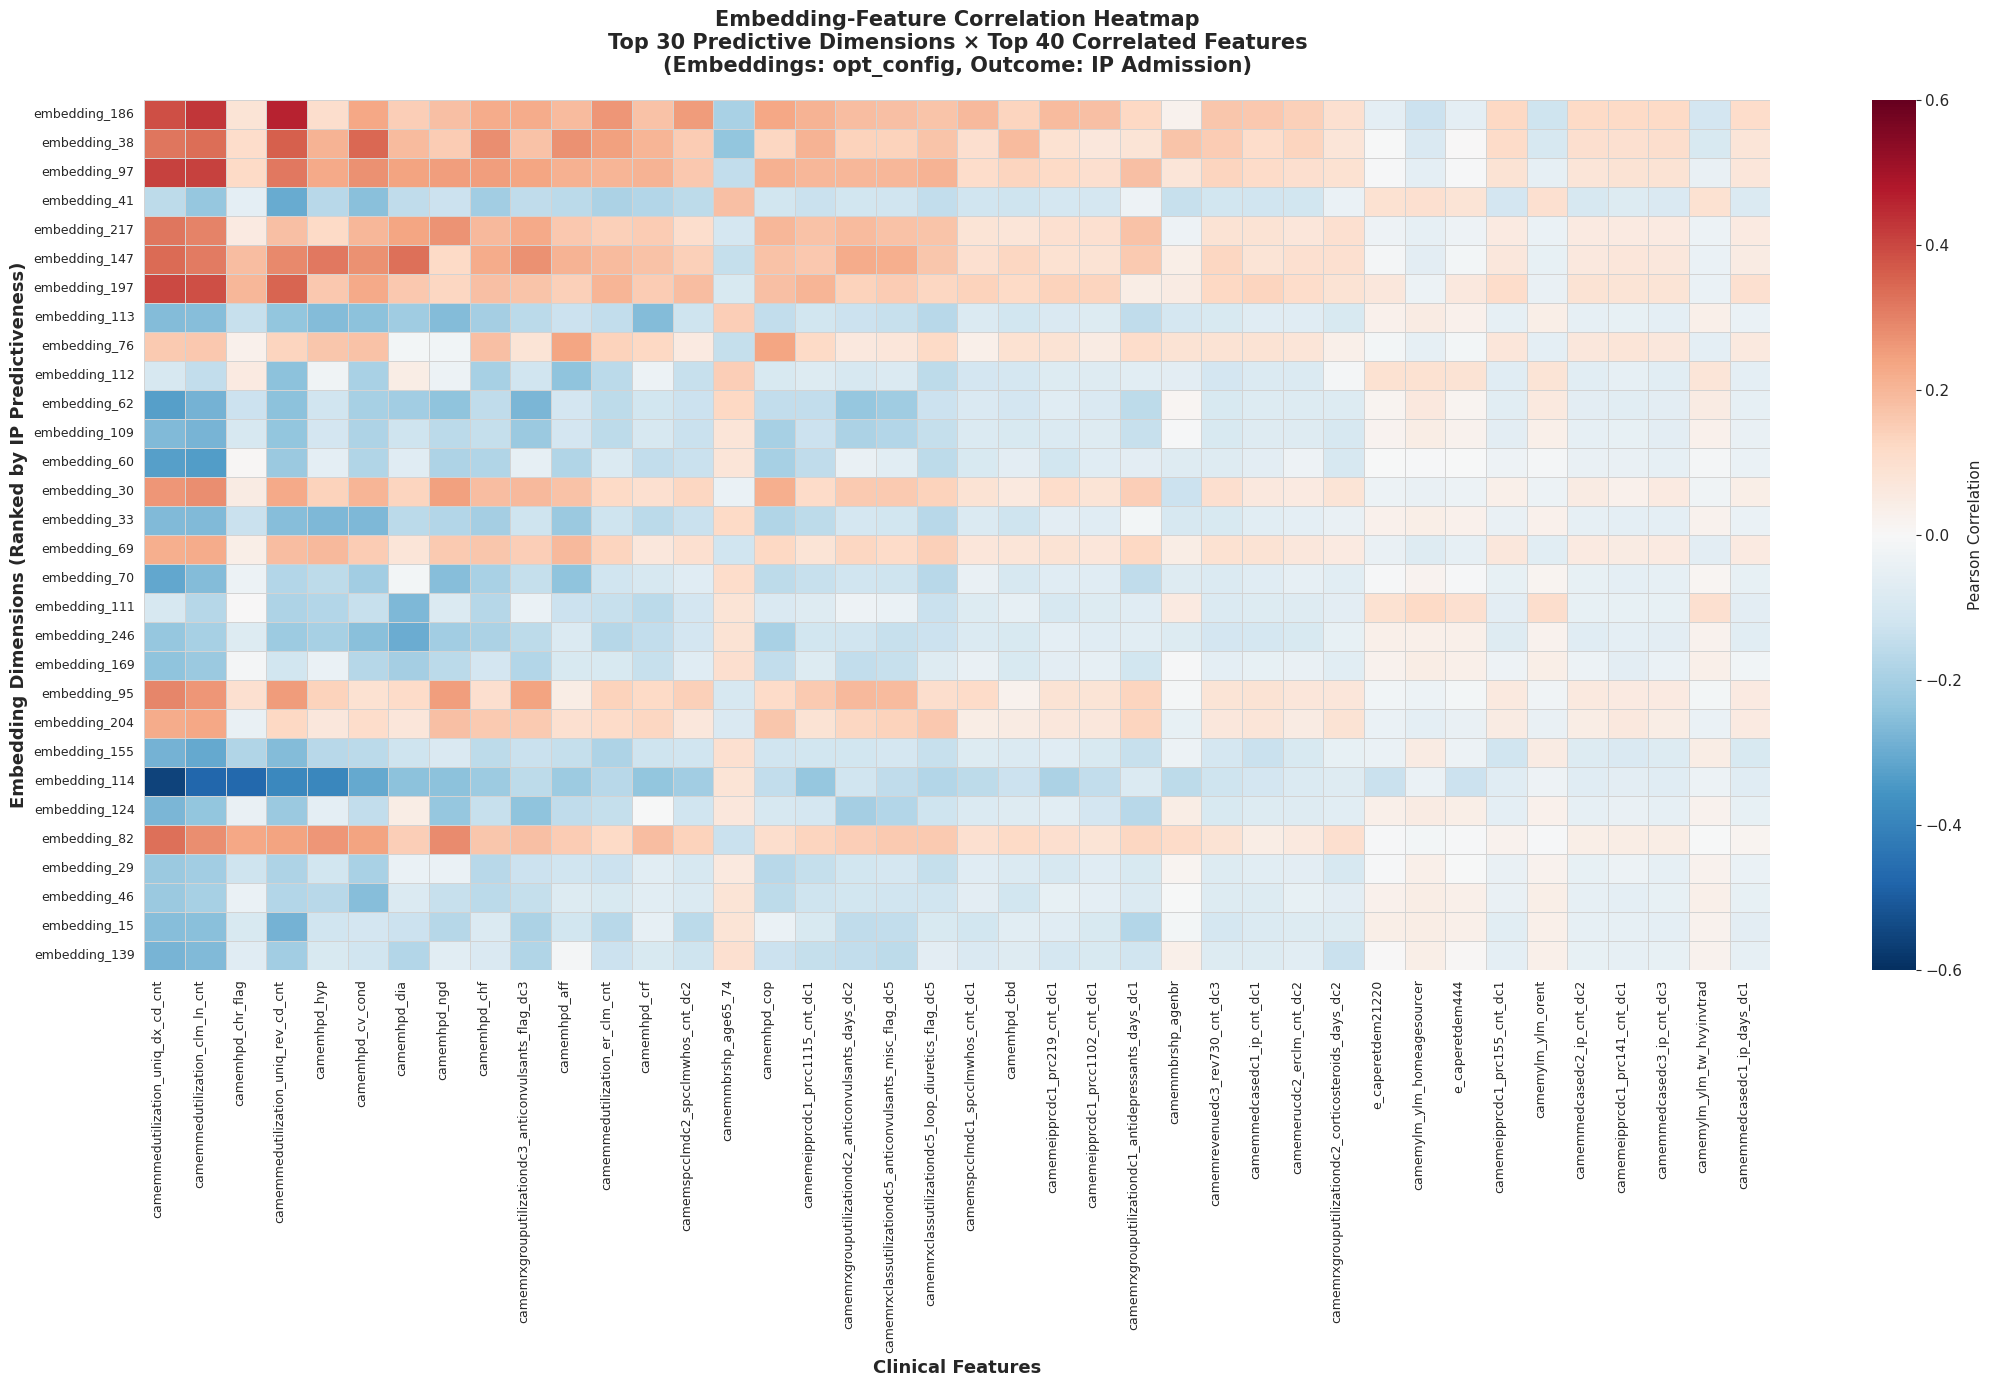


📊 Heatmap shows:
   - Top 30 embedding dimensions (rows)
   - Top 40 most correlated features (columns)
   - Red/Blue = strong correlation (dimension encodes that feature)
   - White = weak correlation (dimension doesn't capture that feature)


In [16]:
print("🎨 Creating correlation heatmap...\n")

# Sort features by max absolute correlation (show most correlated features first)
feature_max_corr = correlation_matrix.abs().max(axis=0).sort_values(ascending=False)
top_features_for_viz = feature_max_corr.head(40).index.tolist()  # Show top 40 features

# Create heatmap
plt.figure(figsize=(22, 14))
sns.heatmap(
    correlation_matrix[top_features_for_viz].astype(float),
    cmap='RdBu_r',
    center=0,
    vmin=-0.6,
    vmax=0.6,
    cbar_kws={'label': 'Pearson Correlation'},
    linewidths=0.5,
    linecolor='lightgray',
    annot=False
)

plt.title(f'Embedding-Feature Correlation Heatmap\n'
          f'Top {len(top_dimensions)} Predictive Dimensions × Top {len(top_features_for_viz)} Correlated Features\n'
          f'(Embeddings: {EMBEDDING_NAME}, Outcome: {OUTCOME_LABEL})',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Clinical Features', fontsize=13, fontweight='bold')
plt.ylabel('Embedding Dimensions (Ranked by IP Predictiveness)', fontsize=13, fontweight='bold')
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\n📊 Heatmap shows:")
print(f"   - Top {len(top_dimensions)} embedding dimensions (rows)")
print(f"   - Top {len(top_features_for_viz)} most correlated features (columns)")
print(f"   - Red/Blue = strong correlation (dimension encodes that feature)")
print(f"   - White = weak correlation (dimension doesn't capture that feature)")

---

## 5. Dimension Interpretation: What Does Each Dimension Mean?

**What this section does:**
- For each of the top N dimensions, shows:
  - **IP Correlation**: How predictive is this dimension?
  - **Top Correlated Features**: What clinical info does it encode?
  - **Clinical Interpretation**: What does this dimension represent?

**This is the final interpretability output!**

In [17]:
print("="*80)
print(f"🧬 EMBEDDING DIMENSION INTERPRETATION")
print("="*80)

for i, dim in enumerate(top_dimensions[:20], 1):  # Show top 20 in detail
    print(f"\n{'='*80}")
    print(f"🔍 Dimension {i}: {dim}")
    print(f"{'='*80}")
    
    # IP correlation
    ip_corr = df_dim_corr[df_dim_corr['dimension'] == dim]['correlation'].values[0]
    print(f"\n📈 IP Admission Correlation: {ip_corr:+.4f}")
    print(f"   {'↑ Higher values → Higher IP risk' if ip_corr > 0 else '↓ Higher values → Lower IP risk'}")
    
    # Top correlated features
    dim_feature_corrs = correlation_matrix.loc[dim].abs().sort_values(ascending=False)
    top_feats = dim_feature_corrs.head(TOP_N_FEATURES_PER_DIM)
    
    print(f"\n📊 Top {TOP_N_FEATURES_PER_DIM} Correlated Clinical Features:")
    print(f"\n   {'Rank':<6} {'Feature':<55} {'Correlation':>12} {'|r|':>8}")
    print(f"   {'-'*6} {'-'*55} {'-'*12} {'-'*8}")
    
    for rank, (feat, abs_corr) in enumerate(top_feats.items(), 1):
        actual_corr = correlation_matrix.loc[dim, feat]
        feat_display = feat[:52] + '...' if len(feat) > 55 else feat
        print(f"   {rank:<6} {feat_display:<55} {actual_corr:>+12.4f} {abs_corr:>8.4f}")
    
    # Clinical interpretation (auto-generated)
    print(f"\n💡 Clinical Interpretation:")
    top_3_features = top_feats.head(3).index.tolist()
    interpretation_hints = []
    
    for feat in top_3_features:
        feat_lower = feat.lower()
        if 'hpd' in feat_lower:
            interpretation_hints.append('chronic disease conditions')
        elif 'ip_cnt' in feat_lower or 'ip_days' in feat_lower:
            interpretation_hints.append('prior hospitalization history')
        elif 'rx' in feat_lower:
            interpretation_hints.append('medication usage patterns')
        elif 'age' in feat_lower:
            interpretation_hints.append('patient age/demographics')
        elif 'expenditure' in feat_lower or feat.startswith('e_'):
            interpretation_hints.append('healthcare expenditure')
        elif 'er' in feat_lower or 'uc' in feat_lower:
            interpretation_hints.append('emergency department utilization')
        elif 'dx' in feat_lower or 'prc' in feat_lower:
            interpretation_hints.append('specific diagnoses/procedures')
        elif 'clm' in feat_lower or 'utilization' in feat_lower:
            interpretation_hints.append('healthcare utilization')
        elif 'ylm' in feat_lower:
            interpretation_hints.append('socioeconomic/demographic factors')
    
    if interpretation_hints:
        interpretation_hints = list(dict.fromkeys(interpretation_hints))  # Remove duplicates, preserve order
        print(f"   → This dimension likely captures: **{', '.join(interpretation_hints)}**")
    else:
        print(f"   → Review top correlated features above for clinical meaning")

print(f"\n\n{'='*80}")
print(f"✅ INTERPRETATION COMPLETE - Top 20 Dimensions Analyzed")
print(f"{'='*80}")

🧬 EMBEDDING DIMENSION INTERPRETATION

🔍 Dimension 1: embedding_186

📈 IP Admission Correlation: +0.1876
   ↑ Higher values → Higher IP risk

📊 Top 10 Correlated Clinical Features:

   Rank   Feature                                                  Correlation      |r|
   ------ ------------------------------------------------------- ------------ --------
   1      camemmedutilization_uniq_rev_cd_cnt                          +0.4612   0.4612
   2      camemmedutilization_clm_ln_cnt                               +0.4302   0.4302
   3      camemmedutilization_uniq_dx_cd_cnt                           +0.3870   0.3870
   4      camemmedutilization_er_clm_cnt                               +0.2659   0.2659
   5      camemspcclmdc2_spcclmwhos_cnt_dc2                            +0.2546   0.2546
   6      camemhpd_cv_cond                                             +0.2323   0.2323
   7      camemhpd_cop                                                 +0.2307   0.2307
   8      camemrxgrouputili

---

## 6. Summary: Key Findings

In [18]:
print("="*80)
print(f"🎯 KEY FINDINGS: What Do Embeddings Capture?")
print("="*80)

# Safety check: Ensure correlation matrix has data
if correlation_matrix.shape[1] == 0:
    print("\n❌ ERROR: No clinical features found for correlation analysis!")
    print("   This means the feature filtering logic excluded all baseline features.")
    print("   Please review the data loading section (Cell 6) and ensure feature_cols is not empty.")
    print("\n   Troubleshooting:")
    print("   1. Check that baseline features table has numeric columns")
    print("   2. Verify outcome_cols list doesn't over-exclude features")
    print("   3. Confirm join succeeded and features are present in df")
else:
    # 1. Overall embedding-feature correlation strength
    strong_corrs = (correlation_matrix.abs() > CORRELATION_THRESHOLD).sum().sum()
    total_corrs = correlation_matrix.shape[0] * correlation_matrix.shape[1]
    pct_strong = strong_corrs / total_corrs * 100
    
    print(f"\n1️⃣ OVERALL EMBEDDING-FEATURE ALIGNMENT:")
    print(f"   - Strong correlations (|r| > {CORRELATION_THRESHOLD}): {strong_corrs:,} / {total_corrs:,} ({pct_strong:.1f}%)")
    print(f"   - Max correlation: {correlation_matrix.abs().max().max():.4f}")
    print(f"   - Mean |correlation|: {correlation_matrix.abs().mean().mean():.4f}")
    
    if pct_strong > 15:
        print(f"   ✅ Embeddings show STRONG alignment with baseline features")
    elif pct_strong > 5:
        print(f"   ⚠️ Embeddings show MODERATE alignment with baseline features")
    else:
        print(f"   📊 Embeddings show WEAK alignment with individual baseline features")
        print(f"   💡 This suggests embeddings capture LATENT patterns via distributed representations!")
    
    # 2. Which features are most represented in embeddings?
    feature_representation = correlation_matrix.abs().max(axis=0).sort_values(ascending=False)
    print(f"\n2️⃣ MOST REPRESENTED CLINICAL FEATURES (in top embedding dimensions):")
    for i, (feat, max_corr) in enumerate(feature_representation.head(15).items(), 1):
        print(f"   {i:2d}. {feat:<55} (max |r| = {max_corr:.4f})")
    
    # 3. Clinical themes
    print(f"\n3️⃣ CLINICAL THEMES IN TOP DIMENSIONS:")
    themes = {}
    for dim in top_dimensions:
        top_feat = correlation_matrix.loc[dim].abs().idxmax()
        feat_lower = top_feat.lower()
        
        if 'hpd' in feat_lower:
            theme = 'Chronic Conditions'
        elif 'ip_cnt' in feat_lower or 'ip_days' in feat_lower:
            theme = 'Prior Hospitalizations'
        elif 'rx' in feat_lower:
            theme = 'Medication Usage'
        elif 'age' in feat_lower:
            theme = 'Demographics/Age'
        elif 'er' in feat_lower or 'uc' in feat_lower:
            theme = 'Emergency Services'
        elif top_feat.startswith('e_'):
            theme = 'Expenditure'
        else:
            theme = 'Healthcare Utilization'
        
        themes[theme] = themes.get(theme, 0) + 1
    
    for theme, count in sorted(themes.items(), key=lambda x: -x[1]):
        print(f"   - {theme}: {count} dimensions")
    
    # 4. Implications
    print(f"\n4️⃣ IMPLICATIONS:")
    max_corr_value = correlation_matrix.abs().max().max()
    if max_corr_value > 0.5:
        print(f"   ✅ Some dimensions are HIGHLY INTERPRETABLE (max |r| = {max_corr_value:.4f})")
        print(f"   ✅ Embeddings strongly encode recognizable clinical patterns")
    elif max_corr_value > 0.3:
        print(f"   ⚠️ Moderate dimension interpretability (max |r| = {max_corr_value:.4f})")
        print(f"   💡 Embeddings use DISTRIBUTED REPRESENTATIONS")
    else:
        print(f"   📊 Low individual feature correlation (max |r| = {max_corr_value:.4f})")
        print(f"   💡 Embeddings encode clinical information across MULTIPLE dimensions")
        print(f"   💡 This is typical of deep learning representations!")
    
    print(f"\n5️⃣ NEXT STEPS:")
    print(f"   📊 Use these dimension interpretations to:")
    print(f"      - Explain model predictions to clinicians")
    print(f"      - Identify if embeddings miss important clinical features")
    print(f"      - Guide feature engineering for hybrid models (embeddings + baseline)")
    print(f"      - Validate that transformer learned clinically meaningful patterns")
    print(f"      - Build trust in embedding-based models")
    
    print(f"{'='*80}")

🎯 KEY FINDINGS: What Do Embeddings Capture?

1️⃣ OVERALL EMBEDDING-FEATURE ALIGNMENT:
   - Strong correlations (|r| > 0.1): 613 / 1,560 (39.3%)
   - Max correlation: 0.5573
   - Mean |correlation|: 0.1066
   ✅ Embeddings show STRONG alignment with baseline features

2️⃣ MOST REPRESENTED CLINICAL FEATURES (in top embedding dimensions):
    1. camemmedutilization_uniq_dx_cd_cnt                      (max |r| = 0.5573)
    2. camemmedutilization_clm_ln_cnt                          (max |r| = 0.4749)
    3. camemhpd_chr_flag                                       (max |r| = 0.4702)
    4. camemmedutilization_uniq_rev_cd_cnt                     (max |r| = 0.4612)
    5. camemhpd_hyp                                            (max |r| = 0.3936)
    6. camemhpd_cv_cond                                        (max |r| = 0.3440)
    7. camemhpd_dia                                            (max |r| = 0.3309)
    8. camemhpd_ngd                                            (max |r| = 0.2842)
    9. 